In [1]:
import time
import seaborn as sns

import Agents
import Instruments
import Markets

import Simulate
import Environment

import numpy as np
from scipy.stats import norm, uniform
import random

import matplotlib.pyplot as plt

import SimPlotting

In [2]:
def initialize_agents(initial_parameters, learning_parameters) -> list:
    
    kwargs = {**initial_parameters, **learning_parameters}
    
    
    Agent_list = [Agents.Agent(**kwargs) for i in range(Nagents)]

    return Agent_list

In [3]:
def initialize_instruments(Nins_1, Nins_2, prod_vec):

    instruments = []

    #means = mean_productivities
    #stds = std_productivities

    for N in range(Nins_1):
        instrument = Instruments.IoP([prod_vec[0], 0])
        instruments.append(instrument)

    for N in range(Nins_2):
        instrument = Instruments.IoP([0, prod_vec[1]])
        instruments.append(instrument)
        
    return instruments

In [4]:
def initialize_allocation(agent_list, instrument_list):
    
    for agent in agent_list:
        
        random_instrument = random.choice(instrument_list)
        instrument_list.remove(random_instrument)
        
        agent.Ins = random_instrument

In [5]:
def initialize_market(market_parameters):
        
    market = Markets.SCDA(**market_parameters)
    
    return market

Initialize Parameters

In [6]:
dt = 1

Nagents = 100

Nactions = 4 # Null, Produce, Consume, Exchange (extra will be allocate when needed)

If we want the macroeconomic condition to be satisfied, then use the below

Define l1 and l2

Then we must define c1 and c2 so that $l_1 c_1 + l_2 c_2 \leq 1$

In [7]:
l1 = 1.0
l2 = 0.5

c1 = 0.1
c2 = 0.3

assert c1 <= 1/l1
c2_max = (1-l1*c1)/l2
assert c2 <= c2_max

condition = l1*c1 + l2*c2
print(condition)
L_nec = condition*Nagents

0.25


In [8]:
cg = np.array([c1, c2])
Nproducts = cg.shape[0]

prod1 = 1./l1
prod2 = 1./l2

This then sets the size of each sector's workforce. 

So we can set the number of instruments available for each sector to match this ratio (scaling to 1 if condition is less than 1)

In [9]:
buffer = 1.0 # How many instruments per agent there are

K1 = int(round(l1*c1/condition*Nagents*buffer,0))
K2 = int(round(l2*c2/condition*Nagents*buffer,0))

K1, K2, K1+K2

(40, 60, 100)

In [10]:
initial_parameters = {
    'Q': np.zeros(Nproducts),
    'D': np.zeros(Nproducts),
    'cg': cg,
    'M': 100.,
    'n_actions': Nactions
}

learning_parameters = {
    'gamma': 0.9,
    'epsilon': 1.0,
    'eps_end': 0.01,
    'eps_dec': 0.01,
    'batch_size': 100,
    'input_dims': [3*Nproducts+2], # If needing to know, check the get_state() function in Simulate class
    'lr': 0.005,
    'n_actions':Nactions,
}

market_parameters = {
    'Nproducts': Nproducts,
    'theta': 0.1,
    'gamma': 1.0,
    'epsilon': 0.005,
    'max_tries': 100,
    'M_min': 0.01,
}


Initialize Agents, Instruments, and Markets

In [11]:
agent_list = initialize_agents(initial_parameters, learning_parameters)
instrument_list = initialize_instruments(K1, K2, [prod1, prod2])

initialize_allocation(agent_list, instrument_list)

market = initialize_market(market_parameters)

In [12]:
for agent in agent_list:
    agent.action_space = [1,2,3]
    
agent_list[-1].action_space

[1, 2, 3]

In [13]:
learn_trigger = -cg.sum()*10

In [14]:
env = Environment.Environment(dt, agent_list, instrument_list, market)
sim = Simulate.Simulate(env)

sim.set_reward_trigger_learn(learn_trigger)


In [15]:
sim.reward_trigger_learn

-4.0

Run Simulation

In [16]:
Ntimes = 500

s = time.perf_counter()
sim.run_simulation(Ntimes)
e = time.perf_counter()

print(e-s)
print((e-s)/60.)
print((e-s)/60./60.)

C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-02-02_Testing_Production_with_Market\2024-02-15_add_timer\Simulate.py:124: RuntimeWarning: invalid value encountered in divide
  self.parray[ti] = self.market.money_exchanged/self.market.quantity_exchanged


323.879844199997
5.397997403333283
0.08996662338888806


In [17]:
sim.reward_trigger_learn

-4.0

Plot

In [18]:
time_ratio = 300/1000

run_ratio = 126.76/646.4

time_ratio, run_ratio

(0.3, 0.19610148514851486)

In [19]:
splt = SimPlotting.SimPlotting(sim)
plt.rcParams['figure.dpi'] = 500

IndexError: index 3 is out of bounds for axis 0 with size 3

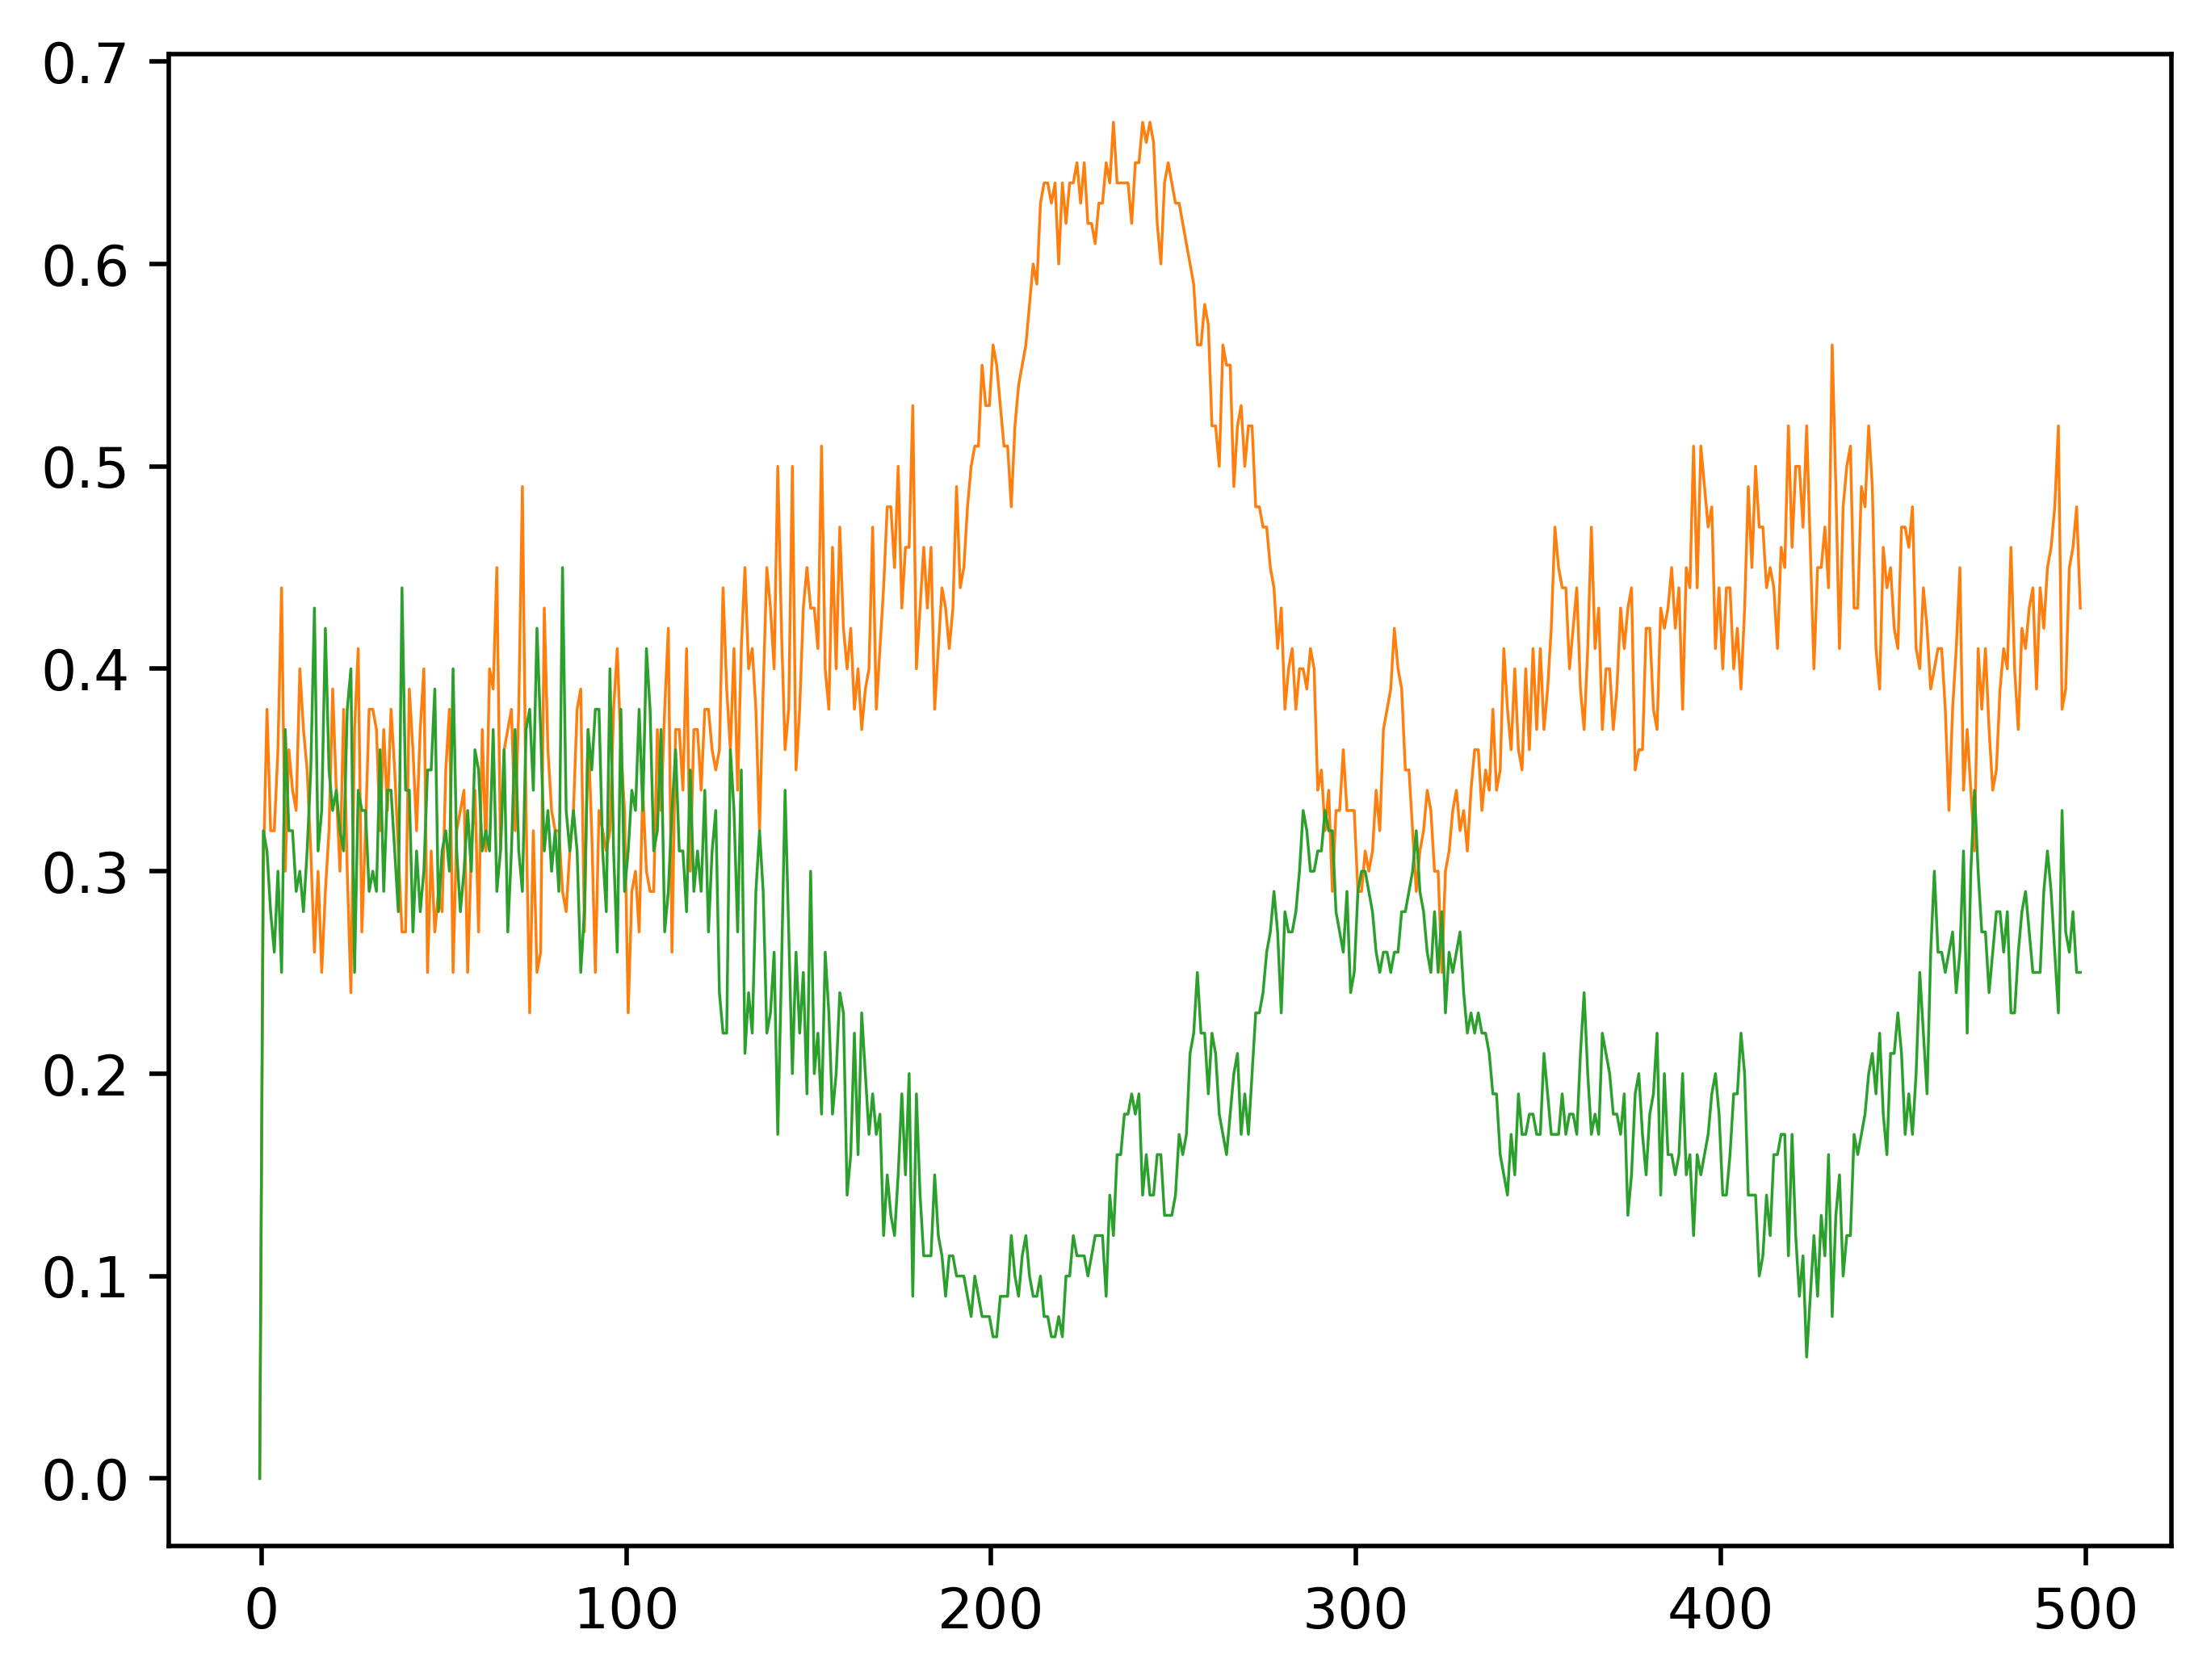

In [20]:
splt.plotA(lw1=0.5, lw2=0.1, ewm=False, alpha=0.01)
plt.axhline(condition, c='orange', lw=1.0, ls=':')
plt.show()

In [ ]:
splt.plotQuantities(
    lw1=0.3, 
    lw2=0.05, 
    xmax=10, 
    tight_layout=True, 
    qlog=False,
    clog=False,
    Qlog=True, 
    Dlog=True, 
    qmin=0, 
    qmax=1, 
    cmin=0, 
    cmax=1,
    Qmin = 1e-1,
    Qmax=1e3,
    Dmin=1e-1,
    Dmax=1e3,
    med=False
)

In [ ]:
splt.plotMarket(lw1=0.3, 
                lw2=0.05, 
                Mlog=False, 
                mNlog=True, 
                mMlog=False, 
                mElog=False, 
                plog=True)

In [ ]:
splt.plotPolicy(0)

In [ ]:
splt.plotPolicy('L')
plt.axhline(condition, c='k', lw=0.5)
plt.show()

In [ ]:
splt.plotPolicy('C')

In [ ]:
splt.plotPolicy('E')

In [ ]:
N1 = 0
N2 = 0
for agent in agent_list:
    xi = agent.Ins.prod_vec
    
    if xi[0] != 0:
        N1 += 1
    elif xi[1] != 0:
        N2 += 1
    else:
        raise ValueError('Agent has Non-Productive Instrument')

In [ ]:
N1, N2

In [ ]:
# The instrument productivities
# ... or the output per instrument
q1_per_ins = 1./l1
q2_per_ins = 1./l2

q1_per_ins, q2_per_ins

In [ ]:
# The total output actually recorded (at each time)
q1_tot = splt.qarray[:,0].sum(axis=1)
q2_tot = splt.qarray[:,1].sum(axis=1)

print(np.nanmean(q1_tot)/Nagents, np.nanmean(q2_tot)/Nagents)
print(np.nanmedian(q1_tot)/Nagents, np.nanmedian(q2_tot)/Nagents)

In [ ]:
# The total workers actually recorded (at each time)
L1 = q1_tot/q1_per_ins
L2 = q2_tot/q2_per_ins

print(np.nanmean(L1), np.nanmean(L2))
print(np.nanmedian(L1), np.nanmedian(L2))

In [ ]:
# The theoretically necessary workers needed to fulfil consumption requirements
L1_nec = cg[0]/q1_per_ins*Nagents
L2_nec = cg[1]/q2_per_ins*Nagents

print(L1_nec, L2_nec)

In [ ]:
# The total consumption actually recorded (at each time)
c1_tot = splt.carray[:,0].sum(axis=1)
c2_tot = splt.carray[:,1].sum(axis=1)

print( round(np.nanmean(c1_tot)/Nagents,2), round(np.nanmean(c2_tot)/Nagents,2) )
print( round(np.nanmedian(c1_tot)/Nagents,2), round(np.nanmedian(c2_tot)/Nagents,2) )

In [ ]:
# the required consumption
print(cg[0], cg[1])

In [ ]:
lw = 0.05
plt.plot(q1_tot, c='C0', lw=lw, label='Output 1')
plt.plot(c1_tot, c='red', lw=lw, label='Consumption 1')
plt.axhline(cg[0]*Nagents, c='r',lw=10*lw, label='Required Consumption 1')
#plt.yscale('log')
plt.legend()
plt.ylabel('$q_1, c_1$')
plt.yscale('log')

In [ ]:
lw = 0.05
plt.plot(q2_tot, c='C0', lw=lw, label='Output 2')
plt.plot(c2_tot, c='red', lw=lw, label='Consumption 2')
plt.axhline(cg[1]*Nagents, c='r',lw=10*lw, label='Required Consumption 2')
#plt.yscale('log')
plt.legend()
plt.ylabel('$q_2, c_2$')
plt.yscale('log')

In [ ]:
lw = 0.05
plt.plot(L1, c='C0', lw=lw, label='$L_1$')
plt.plot(L2, c='C1', lw=lw, label='$L_2$')

plt.axhline(L1_nec, c='blue', label='$L_1$ Required', lw=10*lw)
plt.axhline(L2_nec, c='orange', label='$L_2$ Required', lw=10*lw)
plt.legend()
plt.ylabel('$L_i$')

In [ ]:
ME_df = splt.mMarray
QE_df = splt.mEarray
ntries_df = splt.narray
M_total = splt.Marray
p = splt.parray

def plot_market(i, *, ps=10, log=False, supply_demand=False, show_M_total=False, lw=0.5):

    f, ax = plt.subplots(1, figsize=(10,4)) #(2,1)

    ax.plot(ME_df[:,i], c='C0', label=f'$\Delta M_{i}$', lw=lw)
    ax.plot(QE_df[:,i], c='C1', label=f'$\Delta Q_{i}$', lw=lw)
    ax.plot(ntries_df, c='k', label='Tries', lw=lw)

    #ax.scatter(np.arange(0,T-1), p[:,i], c='g', label=f'$p_{i}$', s=ps)
    ax.plot(p[:,i], c='g', label=f'$p_{i}$', lw=lw)
    
    if supply_demand:
        ax.plot(supply_df[:,i], c='blue', ls='--', label=f'Supply', lw=lw)
        ax.plot(demand_df[:,i], c='orange', ls='--', label=f'Demand', lw=lw)
        
    if show_M_total:
        ax.plot(M_total, c='g', ls=':', label='$M_{total}$', lw=lw)

    ax.legend(bbox_to_anchor=(1, 0.5))
    
    if log:
        plt.yscale('log')
        
    plt.title(f'Market for Commodity {i}')
    plt.xlabel('t')
    plt.ylabel('$M$, $Q$')

In [ ]:
plot_market(0, log=True)
plt.ylim(1e-1, 1e3)

In [ ]:
plot_market(1, log=True)
plt.ylim(1e-1, 1e3)

In [ ]:
plt.plot(sim.parray[:,0], lw=0.1)
plt.plot(sim.parray[:,1], lw=0.1)
plt.yscale('log')
plt.ylabel('$p_i$')

In [ ]:
plt.plot(sim.parray[:,0]/sim.parray[:,1], lw=0.1)
plt.axhline(l1/l2, c='k', lw=0.1)
plt.yscale('log')

In [ ]:
print(l1, l2)
print(l1/l2)

In [ ]:
start_t = 0#6000

In [ ]:
p_mean = np.nanmean(sim.parray[start_t:], axis=0)
print(p_mean)
print(p_mean[0]/p_mean[1])

In [ ]:
l1/l2, p_mean[0]/p_mean[1]

In [ ]:
p_ratio = sim.parray[start_t:,0]/sim.parray[start_t:,1]
np.nanmean(p_ratio), np.nanmedian(p_ratio)

In [ ]:
plt.hist(np.log10(p_ratio))

In [ ]:
np.nanmean(p_ratio), np.nanmedian(p_ratio)

In [ ]:
plt.scatter([l1, l2], p_mean)

In [ ]:
plt.hist(np.log10(sim.parray[:,0]), histtype='step')
plt.hist(np.log10(sim.parray[:,1]), histtype='step')
plt.yscale('log')

In [ ]:
sim.Darray[:,0]

In [ ]:
sim.Darray[Ntimes-1, 1, Nagents-1 ]

In [ ]:
plt.plot(sim.Darray[:, 0, 2])
plt.axhline(cg[0],c='k')
plt.yscale('log')

In [ ]:
plt.plot(sim.Darray[:, 1, 2])
plt.axhline(cg[1], c='k')
plt.yscale('log')

In [ ]:
plt.plot(sim.Darray[:,0,:].mean(axis=1))
plt.plot(sim.Darray[:,0,:].min(axis=1))
plt.plot(sim.Darray[:,0,:].max(axis=1))
plt.plot(np.median(sim.Darray[:,0,:], axis=1))
plt.yscale('log')

In [ ]:
plt.plot(sim.Darray[:,1,:].mean(axis=1))
plt.plot(sim.Darray[:,1,:].min(axis=1))
plt.plot(sim.Darray[:,1,:].max(axis=1))
plt.plot(np.median(sim.Darray[:,1,:], axis=1))
plt.yscale('log')

In [ ]:
sim.Darray[:,0].sum(axis=1)/Nagents

In [ ]:
np.mean(sim.Darray[:,0], axis=1)

In [ ]:
np.median(sim.Qarray[:,1], axis=1)

In [ ]:
plt.plot(sim.Qarray[:,0,:].mean(axis=1))
plt.plot(sim.Qarray[:,0,:].min(axis=1))
plt.plot(sim.Qarray[:,0,:].max(axis=1))
plt.plot(np.median(sim.Qarray[:,0,:], axis=1))
plt.yscale('log')

In [ ]:
splt.plotQi

In [ ]:
i = 1
f'{i:03d}'

In [ ]:
import torch as T

save = False

def save_model(agent, i):
    
    path = f'agent_weights/agent_{i:03d}_weights.pth'
    T.save(agent.QNN.state_dict(), path)

if save:
    for i,agent in enumerate(agent_list):
        save_model(agent, i)
    